# 22 - Rerouting and load redistribution

Our earlier removal tests measure whether deleting a station fragments the graph. That is useful structurally, but it does not capture the usual passenger experience: many trips remain possible and simply take longer. Here we measure closures in added travel time as well as lost reachability.

For each of the `N` structurally critical stations we:

1. find a sample of origin-destination (OD) pairs whose fastest route currently passes through that station;
2. deletes the station from the travel-time graph;
3. recomputes the fastest route for each of those pairs and measures the detour in seconds, along with how many pairs become unreachable;
4. records which other stations now appear in the new routes - the stations that absorb the diverted trips.

This gives us a ranking by passenger-time cost, which we compare with the topological ranking. We want to measure where and how strongly those two views disagree.

**Our question:** *when a critical station goes out of service, how much extra travel time appears in the sampled trips, how many trips become unreachable, and which other stations absorb the rerouted paths?*

We treat this as a scenario model of rerouting around a disabled station.

## Input

* `outputs/nb/18_travel_time_network/tables/edges_traveltime.csv` supplies scheduled travel-time summaries for each directed segment. We need `median_travel_seconds` so path cost is measured in seconds rather than hops.
* `outputs/nb/04_centrality_analysis/tables/stop_metrics.csv` - used only to choose which stations to disable (highest `approx_betweenness`) and to supply names, coordinates and regions.

We do not read the raw `stop_times.txt` again because notebook 18 has already summarized it into segment travel times.

## Required earlier steps

We need stages 01, 02, and 04 for the centrality ranking, plus stage 18 for the travel-time graph.

## Outputs under `outputs/nb/22_rerouting_model/`

* `tables/rerouting_results.csv` - one row per disabled station: `removed_stop, stop_name, mean_detour_seconds, median_detour_seconds, pairs_disconnected, reachable_share, top_absorbing_stops` (plus diagnostic columns).
* `tables/absorbing_stations.csv` - a long-format table: for each removed station, every station that received extra traffic and how many rerouted OD pairs now pass through it.
* `tables/rank_comparison.csv` - topological rank versus passenger-time rank, per station.
* `tables/detour_samples.csv` - the per-OD-pair detours behind the aggregates, so the distributions can be rechecked.
* `rerouting_summary.json` - the main summary values, all the constants that were used, and the fit statistics between the rankings.
* `figures/detour_cost_per_station.png`, `figures/topological_vs_passenger_time_rank.png`, `figures/detour_distribution.png`, `figures/absorbing_stations_worst.png`.

## 1. Setting up the working environment

We begin with the local/Colab setup used across the project. `_ensure(...)` installs missing packages, and `find_repo_root()` locates the GTFS folder or clones the repository in Colab. The cell defines `REPO`, `DATA`, and `OUT` for the rest of the notebook.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Libraries, stage folders and the cost constants

We import the scientific stack plus `scipy.sparse.csgraph`. This notebook needs thousands of shortest-path calculations on roughly 30,000 nodes and 52,000 edges, so we use SciPy's compiled multi-source Dijkstra routine instead of repeated pure-Python NetworkX searches. The graph data remains in the same node-and-edge table format; only the calculation engine changes.

We keep the expensive parameters together in this cell:

| Constant | Default | What it costs |
| --- | --- | --- |
| `TOP_N_STATIONS` | 30 | One multi-source Dijkstra run over the whole graph **per station**. See the note below for why a full scan isn't achievable. |
| `N_SOURCES` | 250 | The all-pairs-from-a-sample baseline via Dijkstra. Memory is `N_SOURCES x n_nodes` for the distances (float64, about 61 MB) plus the same again for the int32 predecessor matrix (about 30 MB). Raising it to 1000 would have needed about 360 MB. |
| `TARGETS_PER_SOURCE` | 80 | 250 x 80 = 20,000 candidate OD pairs. Costs nothing in Dijkstra time - the distances are already computed - only in reconstructing the routes. |
| `MAX_PAIRS_PER_STATION` | 400 | Caps the rerouting work for a very central station. Each rerouted pair needs one pass over the predecessor array. |
| `DISCONNECT_PENALTY_S` | 3600 | Seconds assigned to an unreachable OD pair. This is a scenario assumption, and we also keep the disconnected share separate. |

**Why we do not scan all 30,463 stations:** each removal requires rebuilding the sparse matrix, rerunning multi-source Dijkstra, and having enough sampled through-traffic to estimate a cost. A complete scan would take many hours and would require a much larger OD sample. We restrict the experiment to the top centrality candidates, which makes the run feasible but prevents us from discovering an unexpectedly costly low-betweenness station.

In [2]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'networkx', 'scipy', 'matplotlib', 'seaborn')

import json
import pickle
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', font_scale=1.05)

STAGE = OUT / '22_rerouting_model'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants: the entire cost of this notebook lives here -------
TOP_N_STATIONS        = 30      # stations shut down, one at a time
N_SOURCES             = 250     # origins in the OD sample
TARGETS_PER_SOURCE    = 80      # destinations drawn per origin -> 20,000 OD pairs
MAX_PAIRS_PER_STATION = 400     # cap on rerouted pairs evaluated per removed station
MIN_EDGE_SECONDS      = 1.0     # floor on an edge weight (see note in section 5)
DISCONNECT_PENALTY_S  = 3600.0  # seconds charged to an OD pair that becomes unreachable
TOP_ABSORBING         = 5       # absorbing stations named per removed station
RANDOM_SEED           = 42
FIG_DPI               = 150

rng = np.random.default_rng(RANDOM_SEED)

print('stage folder :', STAGE)
print('OD sample    :', N_SOURCES, 'origins x', TARGETS_PER_SOURCE, 'destinations =',
      N_SOURCES * TARGETS_PER_SOURCE, 'candidate pairs')

stage folder : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model
OD sample    : 250 origins x 80 destinations = 20000 candidate pairs


## 3. Rendering Hebrew labels

Several figures use Hebrew station names. We select fonts with Hebrew glyphs and keep `fix_he()` consistent with this Matplotlib build, which already handles right-to-left ordering. We also remove a stale text patch if present so rerunning the setup does not reverse labels twice.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Locating the input stages

We find the input stages by their two-digit prefixes and search inside them for the required tables. If a file is missing, the helper stops immediately with the stage and filename we need.

In [4]:
# --- Resolve previous stages by two-digit prefix ---------------------------
def stage_dir(prefix, notebook_hint):
    '''Return the output folder of a previous stage, matched by numeric prefix.'''
    matches = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            'No stage folder starting with ' + prefix + ' under ' + str(OUT) +
            ' - run notebook ' + notebook_hint + ' first.')
    return matches[0]


def stage_file(prefix, notebook_hint, filename):
    '''Return the path of `filename` inside a previous stage folder.'''
    folder = stage_dir(prefix, notebook_hint)
    direct = folder / 'tables' / filename
    if direct.exists():
        return direct
    hits = sorted(folder.rglob(filename))
    if not hits:
        raise FileNotFoundError(
            filename + ' not found under ' + str(folder) +
            ' - run notebook ' + notebook_hint + ' first; it writes ' + filename + '.')
    return hits[0]


print('18 ->', stage_dir('18', '18_travel_time_network'))
print('04 ->', stage_dir('04', '04_centrality_analysis'))

18 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network
04 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/04_centrality_analysis


## 5. The travel-time graph from notebook 18

We load `edges_traveltime.csv`, where `median_travel_seconds` summarizes the scheduled time between consecutive stops. We keep the median because unusually long gaps or waits encoded in the schedule would pull a mean upward.

We make three changes before building the sparse graph.

1. **Undirected projection.** We collapse `(u,v)` and `(v,u)` into one edge because removing a station blocks both directions. We keep the faster directional median instead of inventing an average travel time that neither direction provides.
2. **Duplicate aggregation.** CSR construction sums duplicate coordinates, which would incorrectly double a travel time. We group duplicate stop pairs before creating the matrix.
3. **A one-second floor.** SciPy treats a zero in this sparse matrix as no edge, but GTFS can give consecutive stops the same minute. We replace those zero travel times with `MIN_EDGE_SECONDS` and print how many edges were affected.

In [5]:
# --- Load the travel-time edge list written by notebook 18 -----------------
tt_path = stage_file('18', '18_travel_time_network', 'edges_traveltime.csv')
tt = pd.read_csv(tt_path, dtype={'from_stop': str, 'to_stop': str}, encoding='utf-8-sig')

needed = {'from_stop', 'to_stop', 'median_travel_seconds'}
absent = needed - set(tt.columns)
if absent:
    raise KeyError(
        str(tt_path) + ' is missing column(s) ' + str(sorted(absent)) +
        ' - expected the notebook 18 contract '
        '[from_stop, to_stop, median_travel_seconds, ...]. Found: ' + str(sorted(tt.columns)))

before = len(tt)
tt = tt.dropna(subset=['median_travel_seconds']).copy()
tt = tt[tt['from_stop'].astype(str) != tt['to_stop'].astype(str)]
raw_seconds = tt['median_travel_seconds'].astype(float)
n_clamped = int((raw_seconds < MIN_EDGE_SECONDS).sum())
tt['seconds'] = raw_seconds.clip(lower=MIN_EDGE_SECONDS)

# Undirected projection. We first use notebook 18's pooled-median table because it
# matches graph_traveltime.pkl. If that table is unavailable we read the graph pickle,
# and only use the fastest directed median when neither saved artifact is available.
pair = np.sort(tt[['from_stop', 'to_stop']].to_numpy().astype(str), axis=1)
tt['a'] = pair[:, 0]
tt['b'] = pair[:, 1]
direction_counts = tt.groupby(['a', 'b']).size().rename('n_directions')
stage18 = stage_dir('18', '18_travel_time_network')
undirected_path = stage18 / 'tables' / 'edges_traveltime_undirected.csv'
graph_path = stage18 / 'graph_traveltime.pkl'
if undirected_path.exists():
    pooled_edges = pd.read_csv(undirected_path,
                               dtype={'from_stop': str, 'to_stop': str},
                               encoding='utf-8-sig')
    required = {'from_stop', 'to_stop', 'median_travel_seconds'}
    if not required.issubset(pooled_edges.columns):
        raise KeyError(str(undirected_path) + ' has an invalid schema')
    pooled_pair = np.sort(pooled_edges[['from_stop', 'to_stop']].to_numpy().astype(str), axis=1)
    pooled_edges['a'], pooled_edges['b'] = pooled_pair[:, 0], pooled_pair[:, 1]
    und = pooled_edges[['a', 'b', 'median_travel_seconds']].rename(
        columns={'median_travel_seconds': 'seconds'})
    und['seconds'] = pd.to_numeric(und['seconds'], errors='coerce').clip(lower=MIN_EDGE_SECONDS)
    und = und.dropna(subset=['seconds']).drop_duplicates(['a', 'b'])
    und = und.join(direction_counts, on=['a', 'b'])
    print('using pooled-median undirected edges <-', undirected_path)
elif graph_path.exists():
    with open(graph_path, 'rb') as handle:
        travel_graph = pickle.load(handle)
    und = pd.DataFrame([
        {'a': min(str(a), str(b)), 'b': max(str(a), str(b)),
         'seconds': max(float(data.get('travel_seconds', data.get('weight'))),
                        MIN_EDGE_SECONDS)}
        for a, b, data in travel_graph.edges(data=True)
    ])
    und = und.join(direction_counts, on=['a', 'b'])
    print('using pooled-median graph edges <-', graph_path)
else:
    print('WARNING: pooled-median artifact missing; re-run notebook 18. '
          'Using the fastest directed median as a fallback approximation.')
    und = (tt.groupby(['a', 'b'], as_index=False)
             .agg(seconds=('seconds', 'min'), n_directions=('seconds', 'size')))
und['n_directions'] = und['n_directions'].fillna(1).astype(int)

print('travel-time edges read  :', format(before, ','), '<-', tt_path)
print('usable directed edges   :', format(len(tt), ','),
      '(' + format(before - len(tt), ',') + ' dropped: missing time or self-loop)')
print('undirected edges        :', format(len(und), ','))
print('edges clamped to', MIN_EDGE_SECONDS, 'second :', format(n_clamped, ','),
      '(' + format(100 * n_clamped / max(len(tt), 1), '.2f') + '% of usable directed rows)')
print()
print(und['seconds'].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(1))

using pooled-median undirected edges <- /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/tables/edges_traveltime_undirected.csv
travel-time edges read  : 51,898 <- /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/tables/edges_traveltime.csv
usable directed edges   : 51,898 (0 dropped: missing time or self-loop)
undirected edges        : 51,673
edges clamped to 1.0 second : 0 (0.00% of usable directed rows)

count    51673.0
mean       136.3
std        318.3
min          1.0
25%         45.0
50%         66.0
75%        120.0
95%        386.0
max       7078.0
Name: seconds, dtype: float64


## 6. Building the sparse graph and finding the giant component

We map station IDs to integer indices and write the undirected edges into a symmetric CSR matrix. We then label connected components and use the giant component as the OD sampling space.

Pairs in separate components are already unreachable before a closure. Restricting the sample to the giant component gives every pair a finite baseline, so any new infinity is caused by the tested removal.

In [6]:
# --- Integer indexing and the symmetric CSR matrix -------------------------
node_ids = np.unique(np.concatenate([und['a'].to_numpy(), und['b'].to_numpy()]))
index_of = {sid: i for i, sid in enumerate(node_ids)}
n_nodes = len(node_ids)

ai = und['a'].map(index_of).to_numpy(dtype=np.int32)
bi = und['b'].map(index_of).to_numpy(dtype=np.int32)
wt = und['seconds'].to_numpy(dtype=float)

rows = np.concatenate([ai, bi])
cols = np.concatenate([bi, ai])
data = np.concatenate([wt, wt])

BASE = csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))

n_comp, labels = connected_components(BASE, directed=False)
sizes = np.bincount(labels)
giant_label = int(sizes.argmax())
giant_nodes = np.flatnonzero(labels == giant_label)

print('nodes in travel-time graph :', format(n_nodes, ','))
print('undirected edges           :', format(len(und), ','))
print('connected components       :', n_comp)
print('giant component            :', format(len(giant_nodes), ','), 'nodes',
      '(' + format(100 * len(giant_nodes) / n_nodes, '.2f') + '% of the graph)')

nodes in travel-time graph : 30,463
undirected edges           : 51,673
connected components       : 17
giant component            : 30,224 nodes (99.22% of the graph)


## 7. Choosing the stations to disable

We choose the top `TOP_N_STATIONS` from notebook 04's `approx_betweenness`, restricted to stations in the travel-time giant component. Betweenness is a useful screen because a station can affect an OD pair only when the path passes through it. We then test whether that topological ordering also matches travel-time cost.

The source column is normally `approx_betweenness` because notebook 04 uses sampled pivots. The loader accepts a `betweenness` alias when present and otherwise stops rather than constructing a score.

We list any centrality candidates missing from the travel-time graph. Those stations have no usable segment-time path here, so excluding them is a coverage limitation rather than evidence of low cost.

In [7]:
# --- Candidate stations: top-N by approximate betweenness ------------------
metrics_path = stage_file('04', '04_centrality_analysis', 'stop_metrics.csv')
metrics = pd.read_csv(metrics_path, dtype={'stop_id': str}, encoding='utf-8-sig')

btw_col = next((c for c in ('approx_betweenness', 'betweenness') if c in metrics.columns), None)
if btw_col is None:
    raise KeyError(
        str(metrics_path) + ' has no approx_betweenness column - run notebook 04 '
        '(centrality analysis) first. Found: ' + str(sorted(metrics.columns)))
for col in ('stop_name', 'region'):
    if col not in metrics.columns:
        metrics[col] = ''

giant_ids = set(node_ids[giant_nodes].tolist())
ranked = metrics.sort_values(btw_col, ascending=False).reset_index(drop=True)
ranked['topological_rank'] = np.arange(1, len(ranked) + 1)

in_graph = ranked[ranked['stop_id'].isin(giant_ids)]
candidates = in_graph.head(TOP_N_STATIONS).copy().reset_index(drop=True)
# Rank within the shortlist, so the comparison later is 1..N against 1..N.
candidates['topological_rank'] = np.arange(1, len(candidates) + 1)

dropped = ranked.head(TOP_N_STATIONS)[~ranked.head(TOP_N_STATIONS)['stop_id'].isin(giant_ids)]
print('candidate stations         :', len(candidates))
print('top-N stops absent from the travel-time giant component:', len(dropped))
if len(dropped):
    print('  ', list(dropped['stop_id'])[:10])

name_of = dict(zip(metrics['stop_id'].astype(str), metrics['stop_name'].fillna('').astype(str)))
candidates[['stop_id', 'stop_name', 'region', btw_col, 'topological_rank']].head(10)

candidate stations         : 30
top-N stops absent from the travel-time giant component: 0


,stop_id,stop_name,region,approx_betweenness,topological_rank
0,17303,ת.התרעננות/דור אלון מגל 6,Center,0.112456,1
1,41133,מחלף חמד,Jerusalem,0.087533,2
2,27689,מחלף קמה לצפון,South,0.071646,3
3,7444,דרך האר''י/ כביש 375,Jerusalem,0.069168,4
4,41132,מחלף חמד,Jerusalem,0.066711,5
5,7562,שדרות בית הלל/כניסה לעיר,Center,0.065783,6
6,23418,רבי יהודה הנשיא/כניסה לעיר,Center,0.056597,7
7,748,מחלף קסם,Center,0.047271,8
8,29243,תחנת התרעננות/פונדק בית קמה,South,0.046288,9
9,18876,צומת חנניה צומת שבע,North,0.043863,10


## 8. The baseline: sampling OD pairs and finding those that use each candidate

This cell creates the baseline OD sample and identifies which candidates each path uses.

1. We sample `N_SOURCES` origins uniformly from the giant component and run one multi-source Dijkstra call to obtain baseline distances and predecessors.
2. For each origin we sample `TARGETS_PER_SOURCE` reachable destinations.
3. We reconstruct each fastest path by walking backward through the predecessor array.
4. We keep only pairs whose route uses a candidate as an intermediate station. Unaffected pairs are discarded immediately, so we store full routes only for trips relevant to at least one closure.

The retained share tells us how often a uniformly sampled network trip crosses at least one of the screened stations.

The OD sample is uniform over stations, not passengers. A rural pair and a major urban pair receive equal weight, so this is a network scenario rather than a demand-weighted passenger estimate. Notebook 21 provides a population proxy, but we do not combine it with rerouting in this notebook.

In [8]:
# --- Baseline multi-source Dijkstra and the through-traffic index ----------
def reconstruct(pred_row, source_i, target_i):
    '''Walk a scipy predecessor row backwards; return the node path or None.'''
    if target_i == source_i:
        return [int(source_i)]
    path = [int(target_i)]
    cur = int(target_i)
    while cur != source_i:
        cur = int(pred_row[cur])
        if cur < 0:                      # scipy marks no-predecessor as -9999
            return None
        path.append(cur)
    path.reverse()
    return path


cand_index = np.array([index_of[s] for s in candidates['stop_id']], dtype=np.int64)
cand_set = set(int(i) for i in cand_index)

n_src = min(N_SOURCES, len(giant_nodes))
sources = rng.choice(giant_nodes, size=n_src, replace=False)

t0 = time.time()
dist0, pred0 = dijkstra(BASE, directed=False, indices=sources, return_predecessors=True)
print('baseline Dijkstra:', format(time.time() - t0, '.1f'), 's for', n_src, 'origins')

pairs = []        # (source_idx, target_idx, baseline_seconds) for retained pairs only
old_paths = []    # int32 path array, aligned with `pairs`
through = {int(c): [] for c in cand_index}
n_sampled = 0

for r, s_i in enumerate(sources):
    s_i = int(s_i)
    reach = np.flatnonzero(np.isfinite(dist0[r]))
    reach = reach[reach != s_i]
    if reach.size == 0:
        continue
    k = min(TARGETS_PER_SOURCE, reach.size)
    targets = rng.choice(reach, size=k, replace=False)
    prow = pred0[r]
    for t_i in targets:
        t_i = int(t_i)
        n_sampled += 1
        path = reconstruct(prow, s_i, t_i)
        if path is None or len(path) < 3:
            continue                      # no interior stop: nothing to route through
        hits = {nd for nd in path[1:-1] if nd in cand_set}
        if not hits:
            continue
        p = len(pairs)
        pairs.append((s_i, t_i, float(dist0[r, t_i])))
        old_paths.append(np.asarray(path, dtype=np.int32))
        for nd in hits:
            through[nd].append(p)

path_lengths = np.array([len(p) for p in old_paths]) if old_paths else np.array([0])
print('OD pairs sampled                    :', format(n_sampled, ','))
print('pairs routed through a candidate    :', format(len(pairs), ','),
      '(' + format(100 * len(pairs) / max(n_sampled, 1), '.1f') + '% of the sample)')
print('median stops on a retained route    :', int(np.median(path_lengths)))
print('candidates with zero through-traffic:',
      sum(1 for v in through.values() if not v), 'of', len(through))

baseline Dijkstra: 0.9 s for 250 origins
OD pairs sampled                    : 20,000
pairs routed through a candidate    : 10,255 (51.3% of the sample)
median stops on a retained route    : 27
candidates with zero through-traffic: 2 of 30


## 9. The rerouting experiment

`reroute_one` runs one station-closure scenario:

* **Remove the station.** We mask every sparse-matrix entry touching its node index and rebuild the CSR matrix. The isolated node keeps its index, so the stored OD and predecessor indices remain valid.
* **Reroute affected pairs.** We group them by origin and run multi-source Dijkstra only for the origins that need new paths.
* **Measure detour time** as `new_seconds - baseline_seconds`, clipped at zero only to remove floating-point noise.
* **Count unreachable pairs.** We exclude infinite distances from the detour average, save `pairs_disconnected` and `reachable_share`, and include them later through an explicit penalty.
* **Attribute diverted routes.** A station receives one count when it appears in the new path but not the old one. These absorbing-station counts show where the sampled rerouted paths concentrate.

A candidate with no sampled through-traffic gets `pairs_tested = 0` and missing cost statistics, not a false zero. We exclude it from the cost ranking and report the exclusion.

In [9]:
# --- Shut down one station and re-route the trips that used it -------------
def reroute_one(v_idx):
    '''Remove node `v_idx` and re-route every sampled OD pair that used it.'''
    plist = through.get(int(v_idx), [])
    empty = {'pairs_tested': 0, 'pairs_reachable': 0, 'pairs_disconnected': 0,
             'detours': np.array([], dtype=float), 'absorb': {}, 'pair_ids': []}
    if not plist:
        return empty

    if len(plist) > MAX_PAIRS_PER_STATION:
        chosen = rng.choice(np.asarray(plist), size=MAX_PAIRS_PER_STATION, replace=False)
        sel = [int(p) for p in chosen]
    else:
        sel = list(plist)

    keep = (rows != v_idx) & (cols != v_idx)
    Gv = csr_matrix((data[keep], (rows[keep], cols[keep])), shape=(n_nodes, n_nodes))

    src_needed = sorted({pairs[p][0] for p in sel})
    row_of = {s: i for i, s in enumerate(src_needed)}
    dv, pv = dijkstra(Gv, directed=False, indices=src_needed, return_predecessors=True)

    detours, absorb, kept_ids = [], {}, []
    n_disc = 0
    for p in sel:
        s_i, t_i, base = pairs[p]
        r = row_of[s_i]
        new = dv[r, t_i]
        if not np.isfinite(new):
            n_disc += 1
            continue
        detours.append(max(0.0, float(new) - base))
        kept_ids.append(p)
        new_path = reconstruct(pv[r], s_i, t_i)
        if new_path is None:
            continue
        old = set(int(x) for x in old_paths[p])
        for nd in new_path[1:-1]:
            if nd not in old:
                absorb[nd] = absorb.get(nd, 0) + 1

    return {'pairs_tested': len(sel), 'pairs_reachable': len(detours),
            'pairs_disconnected': n_disc, 'detours': np.asarray(detours, dtype=float),
            'absorb': absorb, 'pair_ids': kept_ids}


records, absorb_rows, detour_rows = [], [], []
t_start = time.time()

for pos, row in enumerate(candidates.itertuples(index=False), start=1):
    sid = str(row.stop_id)
    v_idx = index_of[sid]
    out = reroute_one(v_idx)
    d = out['detours']
    tested = out['pairs_tested']

    top_absorb = sorted(out['absorb'].items(), key=lambda kv: kv[1], reverse=True)[:TOP_ABSORBING]
    label = ' | '.join(
        (name_of.get(node_ids[k], '') or node_ids[k]) + ' (' + str(node_ids[k]) + ') x' + str(c)
        for k, c in top_absorb)

    records.append({
        'removed_stop': sid,
        'stop_name': getattr(row, 'stop_name', '') or '',
        'mean_detour_seconds': float(d.mean()) if d.size else np.nan,
        'median_detour_seconds': float(np.median(d)) if d.size else np.nan,
        'pairs_disconnected': int(out['pairs_disconnected']),
        'reachable_share': (out['pairs_reachable'] / tested) if tested else np.nan,
        'top_absorbing_stops': label,
        'pairs_tested': tested,
        'pairs_reachable': int(out['pairs_reachable']),
        'p90_detour_seconds': float(np.percentile(d, 90)) if d.size else np.nan,
        'max_detour_seconds': float(d.max()) if d.size else np.nan,
        'zero_detour_share': float((d <= 1.0).mean()) if d.size else np.nan,
        'approx_betweenness': float(getattr(row, btw_col)),
        'topological_rank': int(row.topological_rank),
        'region': getattr(row, 'region', '') or '',
        'lat': getattr(row, 'lat', np.nan),
        'lon': getattr(row, 'lon', np.nan),
    })

    for k, c in sorted(out['absorb'].items(), key=lambda kv: kv[1], reverse=True):
        absorb_rows.append({'removed_stop': sid,
                            'removed_stop_name': getattr(row, 'stop_name', '') or '',
                            'absorbing_stop': node_ids[k],
                            'absorbing_stop_name': name_of.get(node_ids[k], ''),
                            'displaced_pairs': int(c)})

    for p, sec in zip(out['pair_ids'], d):
        detour_rows.append({'removed_stop': sid,
                            'origin_stop': node_ids[pairs[p][0]],
                            'destination_stop': node_ids[pairs[p][1]],
                            'baseline_seconds': round(pairs[p][2], 1),
                            'detour_seconds': round(float(sec), 1)})

    print(format(pos, '>3'), '/', len(candidates), sid,
          '| tested', format(tested, '>4'),
          '| disconnected', format(out['pairs_disconnected'], '>4'),
          '| mean detour', (format(d.mean() / 60, '.1f') + ' min') if d.size else 'n/a')

print()
print('rerouting sweep finished in', format(time.time() - t_start, '.1f'), 's')

  1 / 30 17303 | tested  157 | disconnected    0 | mean detour 2.5 min
  2 / 30 41133 | tested  400 | disconnected    1 | mean detour 1.5 min
  3 / 30 27689 | tested  400 | disconnected    0 | mean detour 3.5 min
  4 / 30 7444 | tested  400 | disconnected    0 | mean detour 1.7 min
  5 / 30 41132 | tested  400 | disconnected    0 | mean detour 2.5 min
  6 / 30 7562 | tested   63 | disconnected    0 | mean detour 2.5 min
  7 / 30 23418 | tested  400 | disconnected    0 | mean detour 1.3 min
  8 / 30 748 | tested  400 | disconnected    0 | mean detour 1.8 min
  9 / 30 29243 | tested  400 | disconnected    0 | mean detour 2.3 min
 10 / 30 18876 | tested   59 | disconnected    0 | mean detour 0.5 min
 11 / 30 9048 | tested   25 | disconnected    1 | mean detour 1.7 min
 12 / 30 18691 | tested  400 | disconnected    0 | mean detour 1.0 min
 13 / 30 4132 | tested  400 | disconnected    0 | mean detour 2.0 min
 14 / 30 42430 | tested   18 | disconnected    0 | mean detour 1.2 min
 15 / 30 417

## 10. The weighted passenger-time cost, and the two rankings

Mean detour alone cannot rank a station that makes some trips unreachable, because those infinite cases are absent from the average. We therefore define

```
expected_cost_seconds = reachable_share x mean_detour_seconds
                      + (1 - reachable_share) x DISCONNECT_PENALTY_S
```

This is the expected scenario cost for a disrupted sampled pair, using `DISCONNECT_PENALTY_S` for an unreachable trip. The penalty is an assumption. We rerank the stations with 30-minute and three-hour penalties to see whether that choice controls the result.

We compare the passenger-time ranking with the betweenness order using Spearman correlation and top-10 overlap. This shows whether topology identifies the same stations as the rerouting-cost scenario.

In [10]:
# --- Composite cost, rankings and their agreement --------------------------
res = pd.DataFrame(records)

def expected_cost(frame, penalty):
    share = frame['reachable_share']
    mean_d = frame['mean_detour_seconds'].fillna(0.0)
    return share * mean_d + (1.0 - share) * penalty

res['expected_cost_seconds'] = expected_cost(res, DISCONNECT_PENALTY_S)

evaluated = res[res['pairs_tested'] > 0].copy()
skipped = len(res) - len(evaluated)
if evaluated.empty:
    raise RuntimeError('No candidate station carried any sampled through-traffic. '
                       'Raise N_SOURCES / TARGETS_PER_SOURCE and re-run section 8.')

evaluated = evaluated.sort_values('expected_cost_seconds', ascending=False).reset_index(drop=True)
evaluated['passenger_time_rank'] = np.arange(1, len(evaluated) + 1)
evaluated['rank_shift'] = evaluated['topological_rank'] - evaluated['passenger_time_rank']

rho, pval = spearmanr(evaluated['topological_rank'], evaluated['passenger_time_rank'])
k_top = min(10, len(evaluated))
top_topo = set(evaluated.nsmallest(k_top, 'topological_rank')['removed_stop'])
top_time = set(evaluated.nsmallest(k_top, 'passenger_time_rank')['removed_stop'])
overlap = len(top_topo & top_time)

# Sensitivity of the ordering to the disconnection penalty.
# Index [0] rather than .statistic, so this works on every scipy version.
sens = {}
for pen in (1800.0, DISCONNECT_PENALTY_S, 10800.0):
    alt = expected_cost(evaluated, pen).rank(ascending=False, method='min')
    sens['penalty_' + str(int(pen)) + 's_spearman_vs_default'] = round(
        float(spearmanr(alt, evaluated['passenger_time_rank'])[0]), 4)

print('stations evaluated                :', len(evaluated),
      '(' + str(skipped) + ' skipped: no sampled through-traffic)')
print('Spearman rho, topological vs time :', format(rho, '.3f'),
      '(p =', format(pval, '.4f') + ')')
print('top-' + str(k_top) + ' overlap                    :', overlap, 'of', k_top)
print('penalty sensitivity               :', sens)
print()
print('Biggest movers (topological rank -> passenger-time rank):')
movers = evaluated.reindex(evaluated['rank_shift'].abs().sort_values(ascending=False).index)
movers[['removed_stop', 'stop_name', 'topological_rank', 'passenger_time_rank',
        'rank_shift', 'mean_detour_seconds', 'reachable_share']].head(10).round(1)

stations evaluated                : 28 (2 skipped: no sampled through-traffic)
Spearman rho, topological vs time : 0.057 (p = 0.7736)
top-10 overlap                    : 5 of 10
penalty sensitivity               : {'penalty_1800s_spearman_vs_default': 0.9944, 'penalty_3600s_spearman_vs_default': 0.9999, 'penalty_10800s_spearman_vs_default': 0.9911}

Biggest movers (topological rank -> passenger-time rank):


,removed_stop,stop_name,topological_rank,passenger_time_rank,rank_shift,mean_detour_seconds,reachable_share
3,39085,בית ספר ניסויי תפן,30,4,26,180.5,1.0
4,12975,מחלף לה גווארדייה,29,5,24,142.2,1.0
0,19486,תל חי/סיני,24,1,23,278.0,0.3
25,18876,צומת חנניה צומת שבע,10,26,-16,32.2,1.0
17,41133,מחלף חמד,2,18,-16,87.8,1.0
5,14348,מחלף גהה/דרך ז'בוטינסקי,21,6,15,155.1,1.0
20,23418,רבי יהודה הנשיא/כניסה לעיר,7,21,-14,79.4,1.0
24,18691,צומת ראש פינה,12,25,-13,58.8,1.0
13,17934,צומת כישור,26,14,12,104.0,1.0
15,7444,דרך האר''י/ כביש 375,4,16,-12,99.1,1.0


## 11. Writing the tables

We write four UTF-8-with-BOM tables so Hebrew station names open correctly in spreadsheet software.

* **`rerouting_results.csv`** contains one row per closure, with the main detour, reachability, and absorbing-station fields first and diagnostics afterward.
* **`absorbing_stations.csv`** contains every removed-station/absorbing-station pair rather than only the top five.
* **`rank_comparison.csv`** carries the two rankings side by side.
* **`detour_samples.csv`** contains the per-pair values behind the station aggregates, which we can inspect when a summary looks unusual.

In [11]:
# --- Persist the tables ----------------------------------------------------
CONTRACT = ['removed_stop', 'stop_name', 'mean_detour_seconds', 'median_detour_seconds',
            'pairs_disconnected', 'reachable_share', 'top_absorbing_stops']

results = res.merge(
    evaluated[['removed_stop', 'passenger_time_rank', 'rank_shift']],
    on='removed_stop', how='left')
ordered = CONTRACT + [c for c in results.columns if c not in CONTRACT]
results = results[ordered].sort_values('expected_cost_seconds', ascending=False)
results.to_csv(TABLES / 'rerouting_results.csv', index=False, encoding='utf-8-sig')

absorb_df = pd.DataFrame(absorb_rows, columns=['removed_stop', 'removed_stop_name',
                                               'absorbing_stop', 'absorbing_stop_name',
                                               'displaced_pairs'])
absorb_df = absorb_df.sort_values(['removed_stop', 'displaced_pairs'], ascending=[True, False])
absorb_df.to_csv(TABLES / 'absorbing_stations.csv', index=False, encoding='utf-8-sig')

rank_cmp = evaluated[['removed_stop', 'stop_name', 'approx_betweenness', 'topological_rank',
                      'expected_cost_seconds', 'passenger_time_rank', 'rank_shift',
                      'mean_detour_seconds', 'reachable_share', 'pairs_tested']]
rank_cmp.to_csv(TABLES / 'rank_comparison.csv', index=False, encoding='utf-8-sig')

detour_df = pd.DataFrame(detour_rows, columns=['removed_stop', 'origin_stop', 'destination_stop',
                                               'baseline_seconds', 'detour_seconds'])
detour_df.to_csv(TABLES / 'detour_samples.csv', index=False, encoding='utf-8-sig')

for path in ('rerouting_results.csv', 'absorbing_stations.csv',
             'rank_comparison.csv', 'detour_samples.csv'):
    print('wrote', TABLES / path)

results[CONTRACT].head(10)

wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model/tables/rerouting_results.csv
wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model/tables/absorbing_stations.csv
wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model/tables/rank_comparison.csv
wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model/tables/detour_samples.csv


,removed_stop,stop_name,mean_detour_seconds,median_detour_seconds,pairs_disconnected,reachable_share,top_absorbing_stops
23,19486,תל חי/סיני,278.000000,278.0,2,0.333333,קיבוץ מחניים (18955) x1 | צומת מחניים (18704) ...
10,9048,בן גוריון/שערי ירושלים,100.083333,30.5,1,0.960000,ויצמן/גבעת שאול (9046) x14 | מחלף חמד (41132) ...
2,27689,מחלף קמה לצפון,207.081250,163.0,0,1.000000,רבי יהודה הנשיא/חוני המעגל (25419) x136 | צומת...
29,39085,בית ספר ניסויי תפן,180.500000,180.5,0,1.000000,מעלה המסגד/שביל המסגדים (17940) x2 | מעלה המסג...
28,12975,מחלף לה גווארדייה,142.216942,93.0,1,0.995885,דרך קיבוץ גלויות/כביש 1 (13356) x68 | מחלף בית...
20,14348,מחלף גהה/דרך ז'בוטינסקי,155.101250,186.0,0,1.000000,מחלף גהה/דרך ז'בוטינסקי (14077) x205 | מסעף אח...
4,41132,מחלף חמד,152.673750,117.0,0,1.000000,מחלף חמד (41133) x175 | יגאל ידין/דרוק (10226)...
0,17303,ת.התרעננות/דור אלון מגל 6,149.280255,102.5,0,1.000000,צומת מודיעים (גמזו) (21744) x53 | מחלף מסילת צ...
5,7562,שדרות בית הלל/כניסה לעיר,147.380952,91.0,0,1.000000,מסוף מודיעין עילית/הורדה (49800) x43 | שדרות ב...
8,29243,תחנת התרעננות/פונדק בית קמה,137.417500,130.5,0,1.000000,מסעף דימונה/פרץ סנטר (28294) x155 | שדרות אריא...


## 12. Figure 1 - the detour cost per removed station

We plot one bar per disabled station. Bar length is the mean detour among reachable pairs, the ordering follows expected cost, and color shows `reachable_share`. The annotation gives the number of disconnected sampled pairs.

We read bar length and color together: a long light bar means large delays with alternatives still available, while a darker bar means more trips lose connectivity entirely.

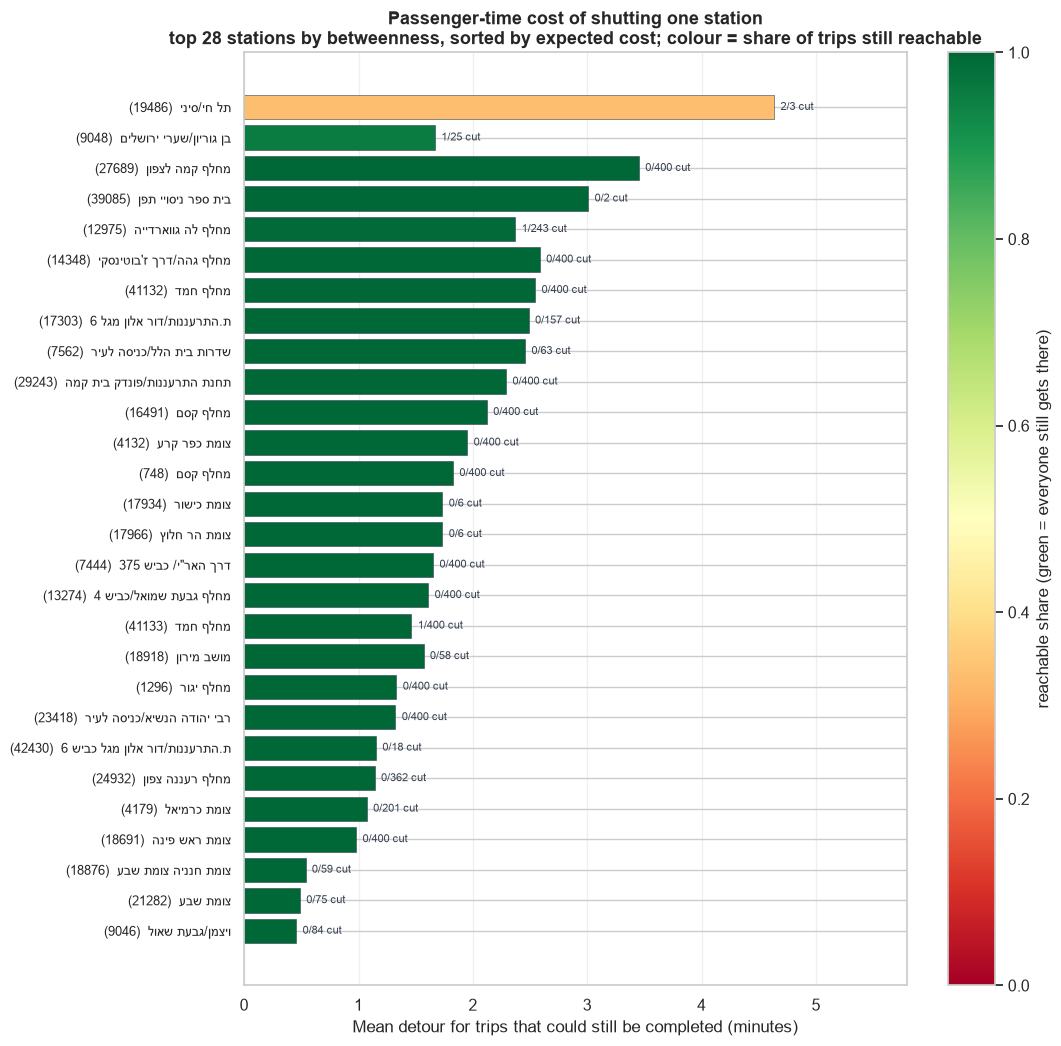

wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model/figures/detour_cost_per_station.png


In [12]:
# --- Figure 1: detour cost per removed station -----------------------------
plot_df = evaluated.copy()
plot_df['mean_detour_min'] = plot_df['mean_detour_seconds'].fillna(0.0) / 60.0
plot_df['label'] = [((nm or '').strip() or sid) + '  (' + sid + ')'
                    for nm, sid in zip(plot_df['stop_name'], plot_df['removed_stop'])]
plot_df = plot_df.sort_values('expected_cost_seconds')      # largest ends on top

cmap = plt.get_cmap('RdYlGn')
colors = [cmap(float(s) if np.isfinite(s) else 1.0) for s in plot_df['reachable_share']]

fig, ax = plt.subplots(figsize=(11, max(6, 0.38 * len(plot_df))))
ax.barh(range(len(plot_df)), plot_df['mean_detour_min'], color=colors,
        edgecolor='#374151', linewidth=0.4)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'], fontsize=9)

span = max(plot_df['mean_detour_min'].max(), 1.0)
for y, (disc, tested) in enumerate(zip(plot_df['pairs_disconnected'], plot_df['pairs_tested'])):
    ax.text(plot_df['mean_detour_min'].iloc[y] + span * 0.012, y,
            str(int(disc)) + '/' + str(int(tested)) + ' cut',
            va='center', fontsize=8, color='#374151')

ax.set_xlim(0, span * 1.25)
ax.set_xlabel('Mean detour for trips that could still be completed (minutes)')
ax.set_title('Passenger-time cost of shutting one station\n'
             'top ' + str(len(plot_df)) + ' stations by betweenness, '
             'sorted by expected cost; colour = share of trips still reachable',
             fontsize=13, fontweight='bold')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])       # required by older matplotlib before it can draw a colorbar
plt.colorbar(sm, ax=ax, label='reachable share (green = everyone still gets there)')
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIGURES / 'detour_cost_per_station.png', dpi=FIG_DPI)
plt.show()
print('wrote', FIGURES / 'detour_cost_per_station.png')

## 13. Figure 2 - topology says one thing, passenger time says another

Each point compares one station's betweenness rank on the x-axis with its expected-cost rank on the y-axis. The diagonal represents identical ranks. Points below it rise in the cost ranking, while points above it fall because the travel-time graph offers cheaper alternatives than their topological position suggests.

We print Spearman rho in the title and label the largest rank differences. A high rho would mean betweenness already gives a similar order and the main addition here is the size of the cost in minutes; a lower rho would mean the two lenses prioritize different stations.

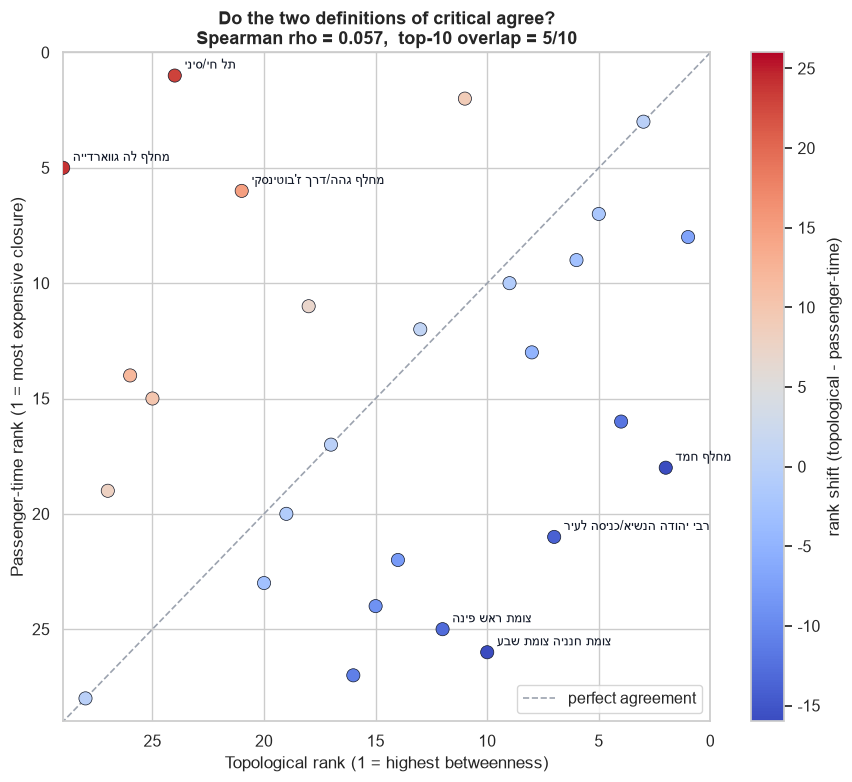

wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model/figures/topological_vs_passenger_time_rank.png


In [13]:
# --- Figure 2: topological rank vs passenger-time rank ---------------------
fig, ax = plt.subplots(figsize=(9, 8))
lim = len(evaluated) + 1
ax.plot([0, lim], [0, lim], '--', color='#9ca3af', linewidth=1.2,
        label='perfect agreement')

sc = ax.scatter(evaluated['topological_rank'], evaluated['passenger_time_rank'],
                s=90, c=evaluated['rank_shift'], cmap='coolwarm',
                edgecolor='#111827', linewidth=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='rank shift (topological - passenger-time)')

n_label = min(8, len(evaluated))
for _, r in movers.head(n_label).iterrows():
    ax.annotate((str(r['stop_name']).strip() or str(r['removed_stop'])),
                (r['topological_rank'], r['passenger_time_rank']),
                textcoords='offset points', xytext=(7, 5), fontsize=9, color='#111827')

ax.set_xlabel('Topological rank (1 = highest betweenness)')
ax.set_ylabel('Passenger-time rank (1 = most expensive closure)')
ax.set_title('Do the two definitions of critical agree?\n'
             'Spearman rho = ' + format(rho, '.3f') + ',  top-' + str(k_top) +
             ' overlap = ' + str(overlap) + '/' + str(k_top),
             fontsize=13, fontweight='bold')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.invert_xaxis()
ax.invert_yaxis()
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES / 'topological_vs_passenger_time_rank.png', dpi=FIG_DPI)
plt.show()
print('wrote', FIGURES / 'topological_vs_passenger_time_rank.png')

## 14. Figure 3 - the shape of the detour distribution

We pool the reachable-pair detours across all closures to inspect their distribution. A peak near zero means many sampled trips find a similar alternative, while a long right tail shows the smaller group with severe delays. We mark the median and 90th percentile because the mean alone hides this difference.

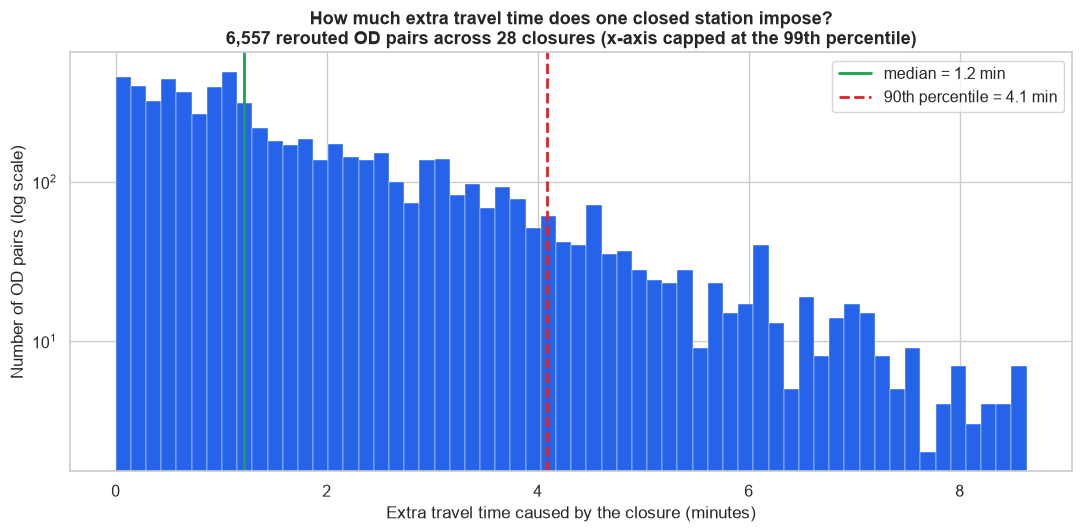

detours (minutes): mean 1.8 | median 1.2 | p90 4.1 | max 39.0
share of rerouted trips with a detour under 1 minute: 39.5%


In [14]:
# --- Figure 3: pooled detour distribution ----------------------------------
all_detours = detour_df['detour_seconds'].to_numpy(dtype=float) / 60.0
if all_detours.size == 0:
    print('No rerouted pairs were recorded - nothing to plot.')
else:
    cap = float(np.percentile(all_detours, 99))
    shown = all_detours[all_detours <= cap]
    med = float(np.median(all_detours))
    p90 = float(np.percentile(all_detours, 90))

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.hist(shown, bins=60, color='#2563eb', edgecolor='white', linewidth=0.3)
    ax.axvline(med, color='#16a34a', linewidth=2,
               label='median = ' + format(med, '.1f') + ' min')
    ax.axvline(p90, color='#dc2626', linewidth=2, linestyle='--',
               label='90th percentile = ' + format(p90, '.1f') + ' min')
    ax.set_yscale('log')
    ax.set_xlabel('Extra travel time caused by the closure (minutes)')
    ax.set_ylabel('Number of OD pairs (log scale)')
    ax.set_title('How much extra travel time does one closed station impose?\n'
                 + format(len(all_detours), ',') + ' rerouted OD pairs across '
                 + str(len(evaluated)) + ' closures (x-axis capped at the 99th percentile)',
                 fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / 'detour_distribution.png', dpi=FIG_DPI)
    plt.show()

    print('detours (minutes): mean', format(all_detours.mean(), '.1f'),
          '| median', format(med, '.1f'),
          '| p90', format(p90, '.1f'),
          '| max', format(all_detours.max(), '.1f'))
    print('share of rerouted trips with a detour under 1 minute:',
          format(100 * float((all_detours < 1.0).mean()), '.1f') + '%')

## 15. Figure 4 - who absorbs the load?

For the highest-cost closure, we rank stations that appear in the new routes but not the original ones. This shows where the sampled diverted paths concentrate and which nearby parts of the network may need attention during that scenario.

These are route counts over sampled OD pairs, not passenger volumes. They identify where the model sends paths, but not how many people would follow them.

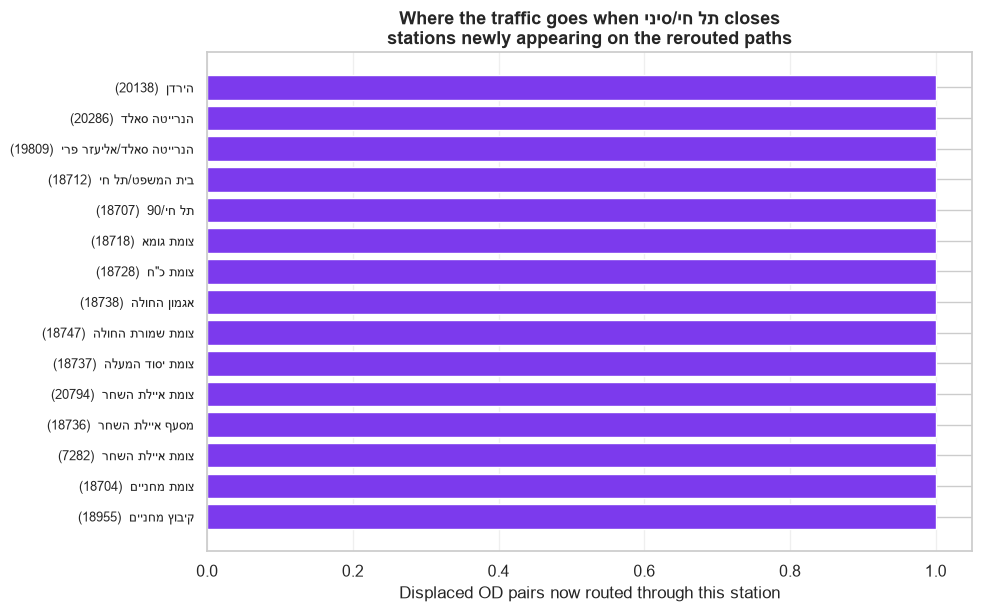

wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model/figures/absorbing_stations_worst.png

Costliest closure: תל חי/סיני (19486)
  mean detour     : 4.6 min
  reachable share : 0.333
  absorbed by     : קיבוץ מחניים (18955) x1 | צומת מחניים (18704) x1 | צומת איילת השחר (7282) x1 | מסעף איילת השחר (18736) x1 | צומת איילת השחר (20794) x1


In [15]:
# --- Figure 4: absorbing stations for the costliest closure ----------------
worst = evaluated.iloc[0]
worst_id = str(worst['removed_stop'])
worst_name = (str(worst['stop_name']).strip() or worst_id)
sub = absorb_df[absorb_df['removed_stop'] == worst_id].head(15).copy()

if sub.empty:
    print('No absorbing stations recorded for', worst_id, '- every rerouted trip kept its path.')
else:
    sub['label'] = [((nm or '').strip() or sid) + '  (' + str(sid) + ')'
                    for nm, sid in zip(sub['absorbing_stop_name'], sub['absorbing_stop'])]
    sub = sub.sort_values('displaced_pairs')

    fig, ax = plt.subplots(figsize=(10, max(5, 0.42 * len(sub))))
    ax.barh(range(len(sub)), sub['displaced_pairs'], color='#7c3aed')
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['label'], fontsize=9)
    ax.set_xlabel('Displaced OD pairs now routed through this station')
    ax.set_title('Where the traffic goes when ' + worst_name + ' closes\n'
                 'stations newly appearing on the rerouted paths',
                 fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(FIGURES / 'absorbing_stations_worst.png', dpi=FIG_DPI)
    plt.show()
    print('wrote', FIGURES / 'absorbing_stations_worst.png')

    print()
    print('Costliest closure:', worst_name, '(' + worst_id + ')')
    print('  mean detour     :', format(worst['mean_detour_seconds'] / 60, '.1f'), 'min')
    print('  reachable share :', format(worst['reachable_share'], '.3f'))
    print('  absorbed by     :', worst['top_absorbing_stops'])

## 16. The JSON summary file

We save the run constants, OD sample size, pooled detour statistics, ranking agreement, and highest-cost closure in `rerouting_summary.json`. Keeping the assumptions beside the results lets us reproduce the exact scenario later.

In [16]:
# --- rerouting_summary.json ------------------------------------------------
pooled = detour_df['detour_seconds'].to_numpy(dtype=float)

summary = {
    'constants': {
        'TOP_N_STATIONS': TOP_N_STATIONS,
        'N_SOURCES': N_SOURCES,
        'TARGETS_PER_SOURCE': TARGETS_PER_SOURCE,
        'MAX_PAIRS_PER_STATION': MAX_PAIRS_PER_STATION,
        'MIN_EDGE_SECONDS': MIN_EDGE_SECONDS,
        'DISCONNECT_PENALTY_S': DISCONNECT_PENALTY_S,
        'RANDOM_SEED': RANDOM_SEED,
    },
    'graph': {
        'source_table': str(tt_path),
        'nodes': int(n_nodes),
        'undirected_edges': int(len(und)),
        'components': int(n_comp),
        'giant_component_nodes': int(len(giant_nodes)),
        'edges_clamped_to_min_seconds': int(n_clamped),
    },
    'od_sample': {
        'pairs_sampled': int(n_sampled),
        'pairs_through_a_candidate': int(len(pairs)),
        'share_through_a_candidate': round(len(pairs) / max(n_sampled, 1), 4),
    },
    'detours_seconds': {
        'rerouted_pairs': int(pooled.size),
        'mean': round(float(pooled.mean()), 1) if pooled.size else None,
        'median': round(float(np.median(pooled)), 1) if pooled.size else None,
        'p90': round(float(np.percentile(pooled, 90)), 1) if pooled.size else None,
        'max': round(float(pooled.max()), 1) if pooled.size else None,
        'share_under_60s': round(float((pooled < 60).mean()), 4) if pooled.size else None,
    },
    'disconnection': {
        'total_pairs_tested': int(res['pairs_tested'].sum()),
        'total_pairs_disconnected': int(res['pairs_disconnected'].sum()),
        'overall_reachable_share': round(
            1 - res['pairs_disconnected'].sum() / max(int(res['pairs_tested'].sum()), 1), 4),
    },
    'rank_agreement': {
        'stations_evaluated': int(len(evaluated)),
        'stations_skipped_no_traffic': int(skipped),
        'spearman_rho': round(float(rho), 4),
        'spearman_p_value': round(float(pval), 6),
        'top_k': int(k_top),
        'top_k_overlap': int(overlap),
        'max_abs_rank_shift': int(evaluated['rank_shift'].abs().max()),
        'penalty_sensitivity': sens,
    },
    'costliest_closure': {
        'stop_id': worst_id,
        'stop_name': str(worst['stop_name']),
        'expected_cost_seconds': round(float(worst['expected_cost_seconds']), 1),
        'mean_detour_seconds': (round(float(worst['mean_detour_seconds']), 1)
                                if np.isfinite(worst['mean_detour_seconds']) else None),
        'reachable_share': round(float(worst['reachable_share']), 4),
        'top_absorbing_stops': str(worst['top_absorbing_stops']),
    },
}

with open(STAGE / 'rerouting_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('wrote', STAGE / 'rerouting_summary.json')
print(json.dumps(summary, ensure_ascii=False, indent=2)[:1600])

wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model/rerouting_summary.json
{
  "constants": {
    "TOP_N_STATIONS": 30,
    "N_SOURCES": 250,
    "TARGETS_PER_SOURCE": 80,
    "MAX_PAIRS_PER_STATION": 400,
    "MIN_EDGE_SECONDS": 1.0,
    "DISCONNECT_PENALTY_S": 3600.0,
    "RANDOM_SEED": 42
  },
  "graph": {
    "source_table": "/Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/tables/edges_traveltime.csv",
    "nodes": 30463,
    "undirected_edges": 51673,
    "components": 17,
    "giant_component_nodes": 30224,
    "edges_clamped_to_min_seconds": 0
  },
  "od_sample": {
    "pairs_sampled": 20000,
    "pairs_through_a_candidate": 10255,
    "share_through_a_candidate": 0.5128
  },
  "detours_seconds": {
    "rerouted_pairs": 6557,
    "mean": 110.6,
    "median": 73.0,
    "p90": 245.0,
    "max": 2343.0,
    "share_under_60s": 0.3953
  },
  "disconnection": {
    "total_pairs_tested": 6562,
 

## 17. Limitations of the rerouting scenario

**1. We do not include walking, waiting, or transfer penalties.** The graph contains in-vehicle segment times only. Real passengers may need to walk, wait, and transfer, so the fastest remaining path is optimistic and the calculated detour is a lower bound on total inconvenience.

**2. Path feasibility does not include frequency.** An edge used once a day and one used every few minutes are both available to Dijkstra. Combining travel time with time-window service frequency would give a more realistic alternative path.

**3. OD pairs are uniform over stations, not passengers.** The model gives an urban pair and a rural pair equal weight. We therefore estimate network travel-time exposure, not total passenger delay. The population proxy from notebook 21 could provide a first weighting, but it is not used here.

**4. The disconnection penalty is assumed.** `DISCONNECT_PENALTY_S = 3600` converts an unreachable pair into a finite scenario cost. We test alternative penalties and keep `mean_detour_seconds` and `reachable_share` as the less assumption-dependent results.

**5. The station costs are sampled.** Each average uses at most `MAX_PAIRS_PER_STATION` affected pairs, and some candidates have far fewer. We save `pairs_tested` and avoid treating small-sample rank differences as precise, even though the fixed seed makes the run reproducible.

**6. We only test the 30 screened stations.** The design can demote a high-betweenness station but cannot discover a costly station outside the candidate set. The measured ranking disagreement is limited to that screened group.

**7. We remove one station at a time.** Corridor closures and simultaneous failures can produce interactions that this experiment does not capture.

**8. Absorbing-station values are sampled route counts.** They show where the model sends alternative paths, not the number of passengers arriving there.

## 18. Conclusions

We tested 30 structurally important station closures against 20,000 sampled origin-destination pairs. The main results are:

* **The sample contains plenty of affected paths.** A baseline shortest path passes through a candidate station for 10,255 pairs, or 51.3% of the sample. We could evaluate 28 candidates; two had no sampled through-traffic and are left out rather than assigned zero cost.

* **Almost all tested pairs reroute, but the delays are not trivial.** Of 6,562 tested affected pairs, 6,557 remain reachable and only five disconnect, for reachability of 99.92%. Across the reachable reroutes, the mean added time is 110.6 seconds, the median is 73.0 seconds, the 90th percentile is 245 seconds, and the maximum is 2,343 seconds. About 39.5% add less than one minute.

* **Topological rank is a weak guide to passenger-time cost in this run.** Spearman agreement is 0.057 with `p=0.774`, the top-10 lists overlap in five stations, and the largest rank shift is 26 places. We therefore keep the two rankings separate instead of presenting one as a substitute for the other.

* **The result is not mainly an artifact of the disconnection penalty.** The passenger-time ordering has Spearman 0.994 when the penalty is 1,800 seconds and 0.991 when it is 10,800 seconds. The costliest tested closure is Tel Hai/Sinai (`19486`), with expected cost 2,492.7 seconds: only 33.33% of its tested pairs remain reachable, and those reachable pairs add 278.0 seconds on average.

* **The absorbing-station table gives us the local rerouting pattern.** `absorbing_stations.csv` records where sampled alternative paths concentrate for each closure, which is more useful for scenario inspection than a single centrality number.

Our conclusion is that component loss misses most of the disruption captured by this experiment: the dominant effect is added travel time. These values are still lower-bound scenario costs, not forecasts, because the graph omits walking, waiting, transfer penalties, frequency, capacity, and observed passenger demand.